## mempraktikan tools" yang dipelajari sebelumnya dengan data asli
untuk memperkuat pemahaman saya mencoba melakukan preprocessing text terhadap data tripadvisor_hotel_reviews.csv

In [23]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
import pandas as pd
import re
import matplotlib.pyplot as plt

In [24]:
data = pd.read_csv('tripadvisor_hotel_reviews.csv')
data.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [25]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Review  109 non-null    str  
 1   Rating  109 non-null    int64
dtypes: int64(1), str(1)
memory usage: 1.8 KB


In [26]:
# membuat tabel baru untuk menambahkan lowercase
data['lowercase'] = data['Review'].str.lower()
data.head()

,Review,Rating,lowercase
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...
3,"unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso..."


In [27]:
# menghapus stopwords pada data reviews
en_stopwords = stopwords.words('english')
data['lowercase_no_stopwords'] = data['lowercase'].apply(lambda x : ' '.join([word for word in x.split() if word not in (en_stopwords)]))
data.head()

,Review,Rating,lowercase,lowercase_no_stopwords
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4* experience hotel monaco seattle ...
3,"unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso..."


In [28]:
#mempertahankan tanda "*" agar tdk terhapus
data['lowercase_no_stopwords'] = data.apply(lambda x: re.sub(r'[*]', ' star', x['lowercase_no_stopwords']), axis = 1)

In [29]:
# menghapus tanda baca pada data
data['lowercase_no_stopwords_no_punct'] = data['lowercase_no_stopwords'].apply(lambda x: re.sub(r'([^\w\s])','',x))
data.head()

,Review,Rating,lowercase,lowercase_no_stopwords,lowercase_no_stopwords_no_punct
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4 star experience hotel monaco seat...,nice rooms 4 star experience hotel monaco seat...
3,"unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


In [30]:
# memecahkan data review dengan word_tokenize
data['tokenized'] = data.apply(lambda x: word_tokenize(x['lowercase_no_stopwords_no_punct']), axis=1)
data.head()

,Review,Rating,lowercase,lowercase_no_stopwords,lowercase_no_stopwords_no_punct,tokenized
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,"[nice, hotel, expensive, parking, got, good, d..."
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,"[ok, nothing, special, charge, diamond, member..."
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4 star experience hotel monaco seat...,nice rooms 4 star experience hotel monaco seat...,"[nice, rooms, 4, star, experience, hotel, mona..."
3,"unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...,"[unique, great, stay, wonderful, time, hotel, ..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...,"[great, stay, great, stay, went, seahawk, game..."


In [31]:
# mengaplikasikan portersetemmer
ps = PorterStemmer()
data['stemmed'] = data['tokenized'].apply(lambda x: [ps.stem(token) for token in x]) 
data.head()

,Review,Rating,lowercase,lowercase_no_stopwords,lowercase_no_stopwords_no_punct,tokenized,stemmed
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,"[nice, hotel, expensive, parking, got, good, d...","[nice, hotel, expens, park, got, good, deal, s..."
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,"[ok, nothing, special, charge, diamond, member...","[ok, noth, special, charg, diamond, member, hi..."
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4 star experience hotel monaco seat...,nice rooms 4 star experience hotel monaco seat...,"[nice, rooms, 4, star, experience, hotel, mona...","[nice, room, 4, star, experi, hotel, monaco, s..."
3,"unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...,"[unique, great, stay, wonderful, time, hotel, ...","[uniqu, great, stay, wonder, time, hotel, mona..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...,"[great, stay, great, stay, went, seahawk, game...","[great, stay, great, stay, went, seahawk, game..."


In [32]:
# mengaplikasikan lemmatizer
lemmatizer = WordNetLemmatizer()
data['lemmatized'] = data['tokenized'].apply(lambda x: [lemmatizer.lemmatize(token) for token in x])
data.head()

,Review,Rating,lowercase,lowercase_no_stopwords,lowercase_no_stopwords_no_punct,tokenized,stemmed,lemmatized
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,"[nice, hotel, expensive, parking, got, good, d...","[nice, hotel, expens, park, got, good, deal, s...","[nice, hotel, expensive, parking, got, good, d..."
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,"[ok, nothing, special, charge, diamond, member...","[ok, noth, special, charg, diamond, member, hi...","[ok, nothing, special, charge, diamond, member..."
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4 star experience hotel monaco seat...,nice rooms 4 star experience hotel monaco seat...,"[nice, rooms, 4, star, experience, hotel, mona...","[nice, room, 4, star, experi, hotel, monaco, s...","[nice, room, 4, star, experience, hotel, monac..."
3,"unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...,"[unique, great, stay, wonderful, time, hotel, ...","[uniqu, great, stay, wonder, time, hotel, mona...","[unique, great, stay, wonderful, time, hotel, ..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...,"[great, stay, great, stay, went, seahawk, game...","[great, stay, great, stay, went, seahawk, game...","[great, stay, great, stay, went, seahawk, game..."


In [33]:
# melakukan identifikasi pada data review yang sudah dibersihkan dengan n-grams
tokens_clean = sum(data['lemmatized'],[])
tokens_clean

['nice',
 'hotel',
 'expensive',
 'parking',
 'got',
 'good',
 'deal',
 'stay',
 'hotel',
 'anniversary',
 'arrived',
 'late',
 'evening',
 'took',
 'advice',
 'previous',
 'review',
 'valet',
 'parking',
 'check',
 'quick',
 'easy',
 'little',
 'disappointed',
 'nonexistent',
 'view',
 'room',
 'room',
 'clean',
 'nice',
 'size',
 'bed',
 'comfortable',
 'woke',
 'stiff',
 'neck',
 'high',
 'pillow',
 'soundproof',
 'like',
 'heard',
 'music',
 'room',
 'night',
 'morning',
 'loud',
 'bang',
 'door',
 'opening',
 'closing',
 'hear',
 'people',
 'talking',
 'hallway',
 'maybe',
 'noisy',
 'neighbor',
 'aveda',
 'bath',
 'product',
 'nice',
 'goldfish',
 'stay',
 'nice',
 'touch',
 'taken',
 'advantage',
 'staying',
 'longer',
 'location',
 'great',
 'walking',
 'distance',
 'shopping',
 'overall',
 'nice',
 'experience',
 'pay',
 '40',
 'parking',
 'night',
 'ok',
 'nothing',
 'special',
 'charge',
 'diamond',
 'member',
 'hilton',
 'decided',
 'chain',
 'shot',
 '20th',
 'anniversary'

Text(0.5, 1.0, '20 Most frequently Occurring unigrams')

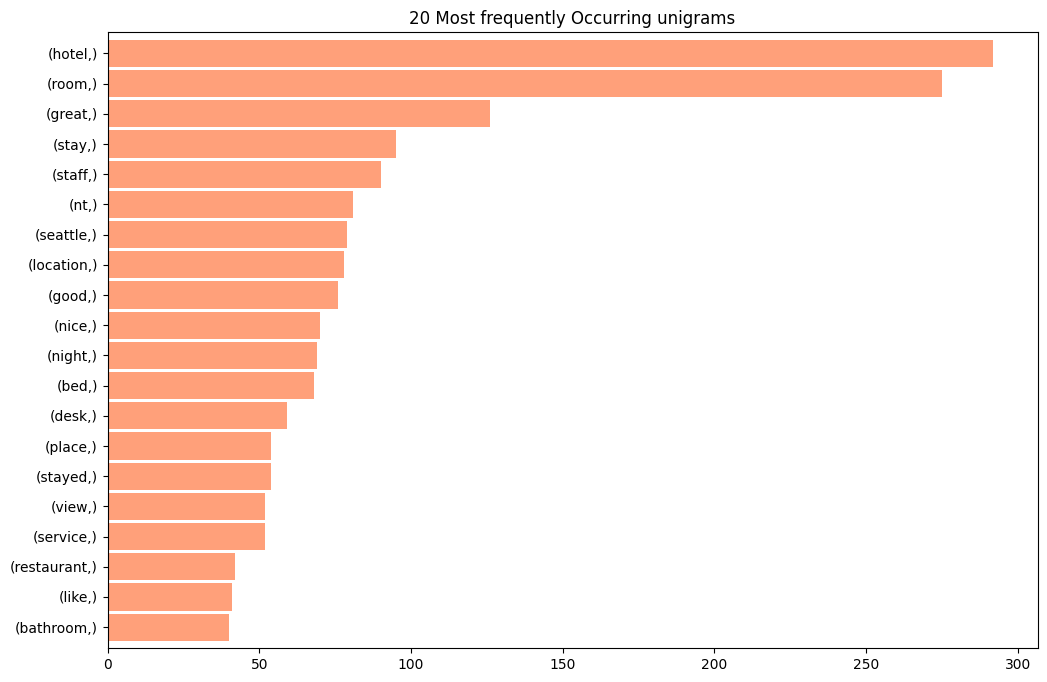

In [34]:
#identifikasi N-grams
unigrams = pd.Series(nltk.ngrams(tokens_clean, 1)).value_counts()
unigrams[:20].sort_values().plot.barh(color='lightsalmon', width = .9, figsize=(12,8))
plt.title('20 Most frequently Occurring unigrams')

In [35]:
bigrams = pd.Series(nltk.ngrams(tokens_clean, 2)).value_counts()
bigrams

(great, location)     24
(space, needle)       21
(hotel, monaco)       16
(staff, friendly)     13
(pike, place)         12
                      ..
(huge, mall)           1
(mall, hotel)          1
(hotel, connected)     1
(connected, good)      1
(food, raffle)         1
Name: count, Length: 8184, dtype: int64

In [36]:
trigrams = pd.Series(nltk.ngrams(tokens_clean, 3)).value_counts()
trigrams

(pike, place, market)         8
(view, space, needle)         5
(hotel, great, location)      5
(staff, friendly, helpful)    5
(room, king, bed)             4
                             ..
(connected, good, food)       1
(good, food, raffle)          1
(food, raffle, hotel)         1
(raffle, hotel, right)        1
(hotel, right, street)        1
Name: count, Length: 9175, dtype: int64